# LC-MS Data Processing
## Tandem Mass Spectrometry Workflow for Compound Identification

This notebook demonstrates how to process Liquid Chromatography-Mass Spectrometry (LC-MS) data using CoreMS, including both MS1 and MS2 (tandem MS) analysis for compound identification.

### Workflow Overview
1. Load LC-MS data from Thermo RAW files
2. Configure MS parameters for MS1 and MS2 data
3. Process mass spectra and extract chromatographic features
4. Perform molecular formula searches on MS1 data
5. Extract and associate MS2 fragmentation data
6. Annotate compounds using MS2 spectral matching
7. Build a molecular network from experimental MS2 spectra
8. Export and visualize results

### Data Format
This tutorial uses Thermo Fisher RAW format LC-MS/MS data files collected in DDA mode.


In [1]:
## Import required packages

import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Keep rendered notebook tables short and readable
pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 100)

from corems.encapsulation.factory.parameters import hush_output, settings_from_lcms
from corems.mass_spectra.input.rawFileReader import ImportMassSpectraThermoMSFileReader
from corems.mass_spectra.output.export import LCMSExport
from corems.molecular_id.search.molecularFormulaSearch import SearchMolecularFormulasLC
from corems.molecular_id.search.database_interfaces import MSPInterface
from corems.molecular_networking import MolecularNetwork


## Read in and parse data

First we'll point an appropriate parser to a data file of the same format.  For instance, for .raw files, we'll use the `ImportMassSpectraThermoMSFileReader`.  Data from .mzml format are also supported, using the `MZMLSpectraParser`. Both parsers are available in the corems.mass_spectra.input module

In [2]:
## Point to file location
file_raw = (
    '../../tests/tests_data/lcms/Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.raw'
)

## Declare/define class object that will parse the raw data
# see corems/corems/mass_spectra/input/rawFileReader.py for more information
# features from this parser can be called from instantiated object
parser = ImportMassSpectraThermoMSFileReader(file_raw)

## Instatiate LC-MS data object as LCMSBase object
# see corems/corems/mass_spectra/factory/lc_class.py for details on LCMSBase object
# pull in MS1 spectra into dataframe (without storing as MassSpectrum objects to save memory)
myLCMSobj = parser.get_lcms_obj(spectra="ms1")


### Available data

After instantiating the `LCMSBase` object, several attributes are available to the user.  We'll walk through a few here.  More documentation is available in the [API documentation](https://emsl-computing.github.io/CoreMS/corems/mass_spectra/factory/lc_class.html).

In [3]:
## The MS1 data (unprocessed) are available in the myLCMSobj object
# values are read in as a dictionary with key '1' which indicates the MS level
# MS2 data has not been added yet
ms1_raw = myLCMSobj._ms_unprocessed[1]
print(f"Unprocessed MS1 dataframe: {ms1_raw.shape[0]:,} rows × {ms1_raw.shape[1]} columns")
ms1_raw.head(5)


Unprocessed MS1 dataframe: 7,696,967 rows × 3 columns


,scan,mz,intensity
0,1.0,200.944397,78.978500
1,1.0,200.944946,180.334900
2,1.0,200.945480,243.672440
3,1.0,200.946014,229.599655
4,1.0,200.946548,146.636734


In [4]:
## Several attributes regarding the scans can be accessed via the `scan_df` property
# This dataframe contains information about each scan in the raw file, regardless of MS level
print(f"scan_df shape: {myLCMSobj.scan_df.shape}")
myLCMSobj.scan_df[["scan", "scan_time", "tic", "ms_level"]].head(5)


scan_df shape: (6840, 10)


,scan,scan_time,tic,ms_level
1,1,0.007275,837892.375000,1
2,2,0.018838,98227.609375,2
3,3,0.044628,7.900221,2
4,4,0.047777,49953.238281,2
5,5,0.066162,117.217705,2


In [5]:
## In dataframe form, easy to call specific series

# TICs (preview)
myLCMSobj.scan_df.tic.head(5)


1    837892.375000
2     98227.609375
3         7.900221
4     49953.238281
5       117.217705
Name: tic, dtype: float64

In [6]:
# Retention times (preview)
myLCMSobj.scan_df.scan_time.head(5)


1    0.007275
2    0.018838
3    0.044628
4    0.047777
5    0.066162
Name: scan_time, dtype: float64

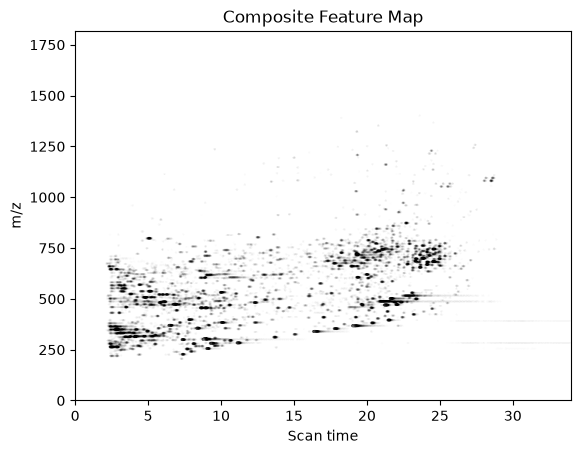

In [7]:
## A visualization of the raw data can be generated
# plots the scan time as the independent variable and the m/z value as the dependent value
# darkness of each point indicates the intensity detected at the m/z value
myLCMSobj.plot_composite_mz_features(mf_plot=False, ms2_plot=False)

## Set Parameters

To perform any data processing, we need to set parameters appropriately.  We'll walk through a few of the available parameters here.  For more complete documentation, see the [API documentation for encapsualted parameters](https://emsl-computing.github.io/CoreMS/corems/encapsulation/factory.html).

In [8]:
## Setting parameters appropriate for experimentation

## Set parameters on the LCMS object that are reasonable for testing (speed things up for this example)
# persistent homology parameters control the thresholds for peak picking, see corems/corems/encapsulation/factory/processSetting.py
# adjusted for demonstration purposes to improve runtime
# based on observation, smoothing does not improve peak picking for these type of data
myLCMSobj.parameters.lc_ms.ph_inten_min_rel = 0.05      # default is 0.001
myLCMSobj.parameters.lc_ms.ph_persis_min_rel = 0.05     # default is 0.001
myLCMSobj.parameters.lc_ms.ph_smooth_it = 0             # default is 1

## MSParameters for ms1 mass spectra
# see corems/corems/encapsulation/factory/parameters.py
## set parameters for how to process an individual mass spectrum object
ms1_params = myLCMSobj.parameters.mass_spectrum["ms1"]
ms1_params.mass_spectrum.noise_threshold_method = "relative_abundance"
ms1_params.mass_spectrum.noise_threshold_min_relative_abundance = 0.1
ms1_params.mass_spectrum.noise_min_mz, ms1_params.mass_spectrum.min_picking_mz = 0, 0
ms1_params.mass_spectrum.noise_max_mz, ms1_params.mass_spectrum.max_picking_mz = (
    np.inf,
    np.inf,
)
ms1_params.ms_peak.legacy_resolving_power = False

## set parameters for how to apply molecular formula searches to MS objects
ms1_params.molecular_search.url_database = (
    ""  ## this will default to using a local sqlite database
)
ms1_params.molecular_search.usedAtoms = {
    "C": (10, 30),  # default (1, 90)
    "H": (18, 200),  # default (4, 200)
    "O": (1, 23),  # default (0, 12)
    "N": (0, 3),  # default (0, 0)
    "P": (0, 1),  # default (0, 0)
    "S": (0, 1),  # default (0, 0)
}

## settings for MS2 data (HCD scans), same as ms1_params
# for these example data, we have HCD scans that are similar to MS1 scans in resolution, so we'll use the same parameters
# see corems/corems/encapsulation/factory/processSetting.py
ms2_params_hcd = ms1_params.copy()
myLCMSobj.parameters.mass_spectrum["ms2"] = ms2_params_hcd

## settings for ms2 data (CID scans), one change from ms1_params
# for these example data, we have CID scans that are lower resolution than MS1 scans, 
# so we'll use slightly different parameters for processing those spectra
# lower noise threshold for CID scans
ms2_params_cid = ms2_params_hcd.copy()
ms2_params_cid.mass_spectrum.noise_threshold_min_relative_abundance = 0.01
myLCMSobj.parameters.mass_spectrum["ms2_cid"] = ms2_params_cid

# Quiet progress bars / class-by-class formula-search messages for a cleaner notebook
hush_output()
myLCMSobj.parameters.lc_ms.verbose_processing = False
for _key, _ms_params in myLCMSobj.parameters.mass_spectrum.items():
    _ms_params.mass_spectrum.verbose_processing = False
    _ms_params.molecular_search.verbose_processing = False


## Identify MS1 M/Z features

The first step for processing these data will be to identify m/z features (unique m/z x retention time pairs) in the data.  We'll use an approach based on persitent homology to do this. 

In [9]:
## Identify the MZ features from the raw data using the persistent homology method
# see corems/corems/mass_spectra/calc/lc_calc.py
myLCMSobj.find_mass_features()

## The previous function generated a summarizing dataframe to quickly reference the identified attributes
# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 50 rows × 20 columns


,type,scan_time,mz,apex_scan
mf_id,,,,
0,untargeted,8.895637,301.216614,1882.0
1,untargeted,19.152648,367.357483,4069.0
2,untargeted,16.438137,339.326111,3484.0
3,untargeted,8.378137,355.321167,1756.0
4,untargeted,6.515803,369.300629,1297.0


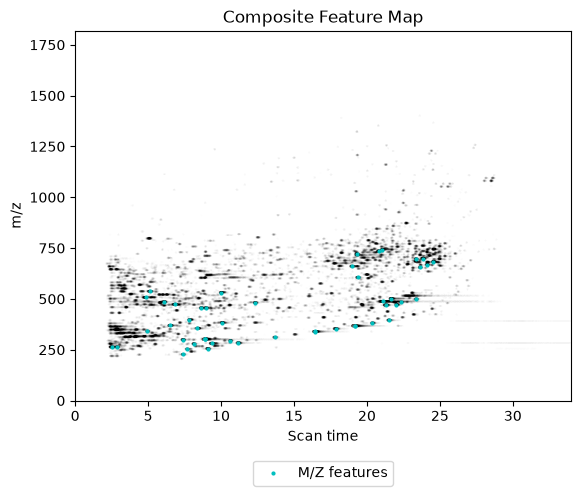

In [10]:
## After calling .find_mass_features, the raw data plot can now be recreated with M/Z features highlighted in blue
myLCMSobj.plot_composite_mz_features(ms2_plot=False)

In [11]:
## Calls exist to easily retrieve MZ feature specific data
# Call the first MZ feature (index 0)
# List of available properties found in corems/corems/chroma_peak/factory/chroma_peak_classes.py, LCMSMassFeature class
# 'Scan time' is used interchangably with 'Retention time'
myLCMSobj.mass_features[0].retention_time

8.895636666666666

In [12]:
myLCMSobj.mass_features[0].mz

301.21661376953125

In [13]:
myLCMSobj.mass_features[0].intensity

66775328.0

## Add the associated MS1 spectra

Next we'll add the MS1 spectra to the data object.  This will allow us to perform further processing specifically on the MS1 spectra using functionality in the `corems.mass_spectrum` module.

In [14]:
## Instantiate Mass Spectrum objects and store on LCMS object
# this will only add MS1 specttra to the object that are associated with the MZ features
# we will automatically process the MS1 spectra (`auto_process=True`) since we've set our parameters for processing
# we will not use the parser to process the data (`use_parser=False`) since we've already parsed the ms1 data from the raw file
# we will set the spectrum mode to 'profile' since these are profile data, and the process is much faster if we declare the spectrum mode
myLCMSobj.add_associated_ms1(
    auto_process=True, use_parser=False, spectrum_mode="profile"
)

In [15]:
# This call does not add any new information to the .mass_features_to_df() result
# Instead, examine the properties of the identified MS1 which can be called by their identification keys
ms_keys = list(myLCMSobj.ms.keys())
print(f"MS1 spectra associated with mass features: {len(ms_keys)} (showing first 10 keys)")
print(ms_keys[:10])


MS1 spectra associated with mass features: 45 (showing first 10 keys)
[271, 370, 883, 910, 955, 1198, 1297, 1378, 1513, 1585]


In [16]:
# Mass Spectrum objects inhereit properties from MassSpecBase class, corems/corems/mass_spectrum/factory/MassSpectrumClasses.py
# Examine sample spectrum
key = list(myLCMSobj.ms.keys())[0]

## Sample attributes that are now stored on the myLCMS object
print("Abundances as array:")
print(myLCMSobj.ms[key].abundance)
print()
print("M/Z values as array:")
print(myLCMSobj.ms[key].mz_exp)
print()
print("Total ion current of mass spectrum:")
print(myLCMSobj.ms[key].tic)

Abundances as array:
[19102.68164062 16486.91992188 12420.82617188 ... 47565.3515625
 17303.453125   23495.61914062]

M/Z values as array:
[ 201.12873571  207.06647899  207.13928165 ... 1860.54140956 1924.33663261
 1958.86048751]

Total ion current of mass spectrum:
13535584.304467887


<Axes: xlabel='$\t{m/z}$', ylabel='Abundance'>

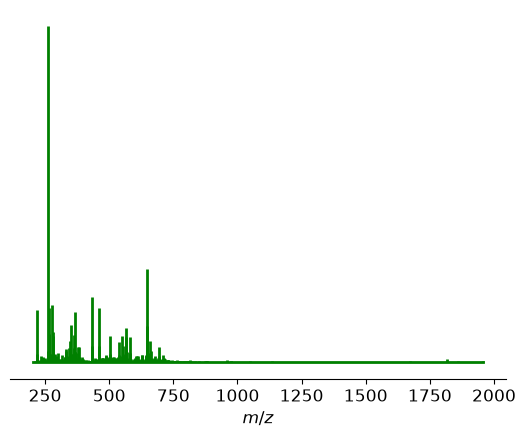

In [17]:
## Visualize the identified spectrum
myLCMSobj._ms[key].plot_centroid()

## Integrate M/Z Features

For the next step, we'll integrate the m/z features to get the intensity and area under the curve for each feature.  This will pull in extracted ion chromatograms (EICs) for each unique m/z value in the m/z features and integrate the area under the curve for each feature.

In [18]:
## Integrate mass features and extract EICs
# fills in the start_scan, final_scan, and area values for the M/Z features
# drop_if_fail argument discards M/Z features that fail to find a left and right limit on a peak
# see corems/corems/mass_spectra/calc/lc_calc.py
myLCMSobj.integrate_mass_features(drop_if_fail=True)

# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan", "start_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 49 rows × 20 columns


,type,scan_time,mz,apex_scan,start_scan
mf_id,,,,,
0,untargeted,8.895637,301.216844,1882.0,1828
1,untargeted,19.152648,367.357482,4069.0,4024
2,untargeted,16.438137,339.326190,3484.0,3448
3,untargeted,8.378137,355.321396,1756.0,1729
4,untargeted,6.515803,369.300726,1297.0,1261


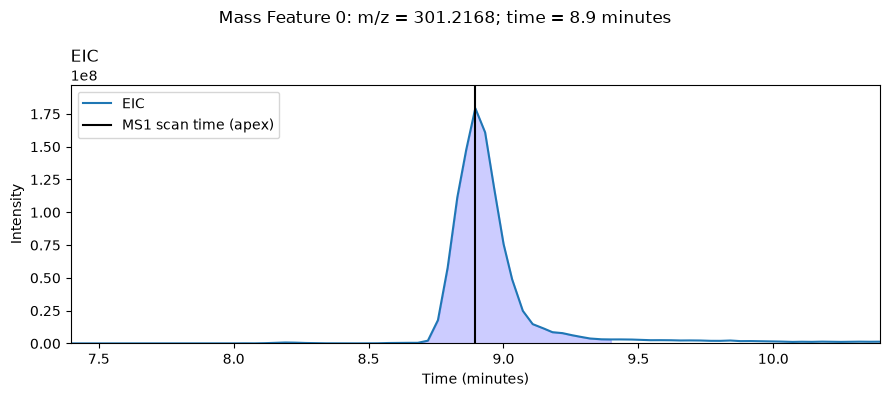

In [19]:
# Generate visualizations of M/Z features
# see more options at corems/chroma_peak/factory/chroma_peak_classes.py
myLCMSobj.mass_features[0].plot(to_plot=["EIC"], return_fig=False)

## Deconvolute MS1 M/Z features

The MS1 spectra associated with each m/z feature can be deconvoluted across the retention time dimension to identify the m/z peaks within the ms1 spectra that are associated with the m/z feature.  This will help us to identify the m/z peaks that are associated with each m/z feature.

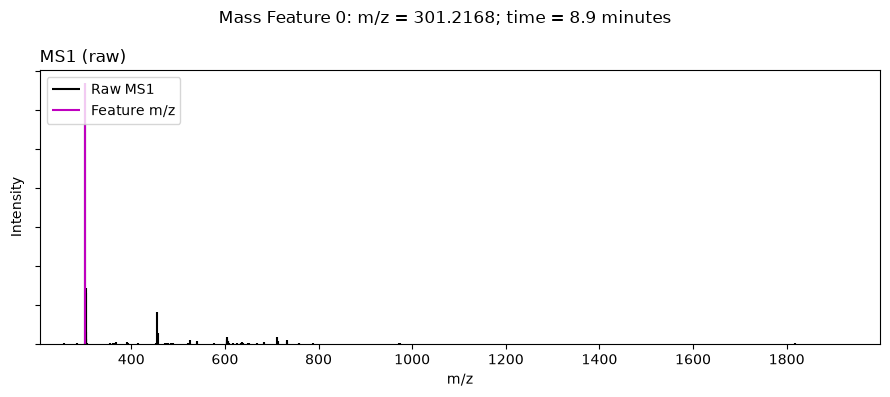

In [20]:
# Visualize raw MS1 M/Z feature
myLCMSobj.mass_features[0].plot(to_plot=["MS1"], return_fig=False)

In [21]:
## Deconvolute the MS1 M/Z features
# Identifies each M/Z feature with boolean indicating if mass_spectrum_deconvoluted_parent exists
# see corems/corems/mass_spectra/calc/lc_calc.py
myLCMSobj.deconvolute_ms1_mass_features()

# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan", "start_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 49 rows × 21 columns


,type,scan_time,mz,apex_scan,start_scan
mf_id,,,,,
0,untargeted,8.895637,301.216844,1882.0,1828
1,untargeted,19.152648,367.357482,4069.0,4024
2,untargeted,16.438137,339.326190,3484.0,3448
3,untargeted,8.378137,355.321396,1756.0,1729
4,untargeted,6.515803,369.300726,1297.0,1261


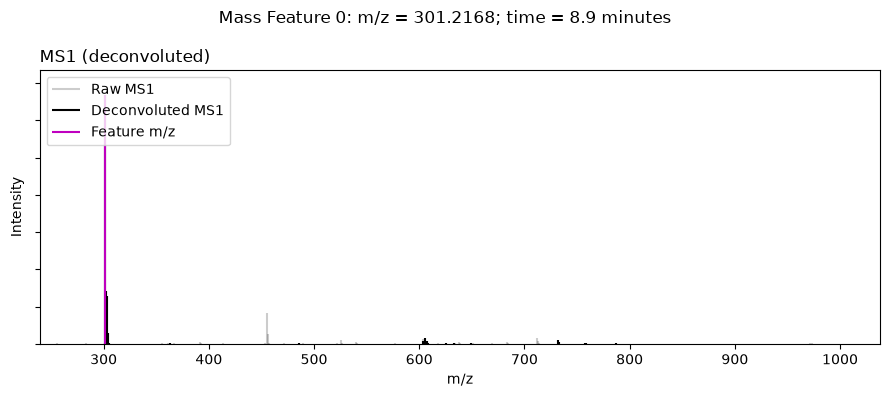

In [22]:
# Visualize deconvoluted MS1 M/Z feature
myLCMSobj.mass_features[0].plot(to_plot=["MS1"], return_fig=False)

## Add additional peak shape 

This next step will add additional peak shape information to each of the m/z features on the data object.  These include half height width, tailing factor, and dispersity index.

In [23]:
## Add more peak metrics, see corems/corems/mass_spectra/calc/lc_calc.py
# fills in dispersity_index and adds columns half_height_width and tailing_factor when possible
myLCMSobj.add_peak_metrics()

# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan", "start_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 49 rows × 22 columns


,type,scan_time,mz,apex_scan,start_scan
mf_id,,,,,
0,untargeted,8.895637,301.216844,1882.0,1828
1,untargeted,19.152648,367.357482,4069.0,4024
2,untargeted,16.438137,339.326190,3484.0,3448
3,untargeted,8.378137,355.321396,1756.0,1729
4,untargeted,6.515803,369.300726,1297.0,1261


## Mark isotope peaks

We use the `find_c13_mass_features` method to identify likely 13C isotopic peaks in the data.

In [24]:
## Mark likely C13 isotopes and connect to M/Z features
# see corems/corems/mass_spectra/calc/lc_calc.py
myLCMSobj.find_c13_mass_features()

# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan", "start_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 49 rows × 22 columns


,type,scan_time,mz,apex_scan,start_scan
mf_id,,,,,
0,untargeted,8.895637,301.216844,1882.0,1828
1,untargeted,19.152648,367.357482,4069.0,4024
2,untargeted,16.438137,339.326190,3484.0,3448
3,untargeted,8.378137,355.321396,1756.0,1729
4,untargeted,6.515803,369.300726,1297.0,1261


## Molecular formula search for m/z features

Next we'll perform a search for molecular formula associated with each m/z feature.  This will use the m/z value and the associated MS1 spectra to search for molecular formula that are likely to be associated with each m/z feature.

In [25]:
## Perform a molecular search on all of the M/Z features' ms1 peaks
# see corems/corems/molecular_id/search/molecularFormulaSearch.py
# SearchMolecularFormulasLC() is a class and run_mass_feature_search() peforms the search
mol_form_search = SearchMolecularFormulasLC(myLCMSobj)
mol_form_search.run_mass_feature_search()

In [26]:
# Examine one peak in one M/Z feature
myLCMSobj.mass_features[0].ms1_peak[0].string

'C20 H30 O2'

In [27]:
# Summarize the MS1 annotations for the M/Z features as a dataframe
# see corems/corems/mass_spectra/factory/lc_class.py
annot_df = myLCMSobj.mass_features_ms1_annot_to_df()
print(f"MS1 annotations: {len(annot_df)} rows × {annot_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["m/z", "Calibrated m/z", "Calculated m/z", "Peak Height", "Peak Area"] if c in annot_df.columns]
annot_df[_cols].head(5)


MS1 annotations: 98 rows × 33 columns


,m/z,Calibrated m/z,Calculated m/z,Peak Height,Peak Area
mf_id,,,,,
0,301.216844,301.216844,301.217304,66775328.0,207870.960423
1,367.357482,367.357482,367.358154,48137056.0,257301.948288
2,339.326190,339.326190,339.326854,35888348.0,166884.343737
3,355.321396,355.321396,355.321769,25525068.0,119802.079339
4,369.300726,369.300726,369.301033,25392018.0,123970.862580


In [28]:
# Examine the MS1 annotations for just one M/Z feature
ms1_annots = myLCMSobj.mass_features[0].mass_spectrum.to_dataframe()
print(f"Peaks in this MS1 spectrum dataframe: {len(ms1_annots)}")
# Short readable preview (full table is wide)
_cols = [c for c in ["Index", "m/z", "Calibrated m/z", "Calculated m/z", "Peak Height"] if c in ms1_annots.columns]
ms1_annots[_cols].head(5)

# Note that the run_mass_feature_search() method only searches the m/z values associated with m/z features, not the entire MS1 spectra, 
# which is why the number of annotations is very low when looking at the entire MS1 spectra


Peaks in this MS1 spectrum dataframe: 106


,Index,m/z,Calibrated m/z,Calculated m/z,Peak Height
0,4,301.216844,301.216844,301.217304,6.677533e+07
1,6,302.220226,302.220226,302.220659,1.424971e+07
2,7,303.224701,303.224701,303.224013,1.177640e+06
3,0,255.232873,255.232873,NaN,2.853830e+05
4,1,283.264145,283.264145,NaN,1.872186e+05


## MS2 data

Next we'll add MS2 data to the data object.

In [29]:
## Add MS2 spectra associated with mass features to the data set
# populates the ms2_scan_numbers attribute in the mass_features dictionary
# see corems/corems/mass_spectra/factory/lc_class.py

# Add HCD MS2 data using the ms2 mass spectrum parameters
# we'll set the spectrum mode to 'centroid' since these are centroid data, and the process is much faster if we declare the spectrum mode
# we'll set the scan filter to 'hcd' since we only want to add the hcd scans first
# by default, these will be added using the parser, will be automatically processed, and will be associated with the mass spectrum parameters we set in the "ms2" slot
myLCMSobj.add_associated_ms2_dda(spectrum_mode="centroid", scan_filter="hcd")

# Add CID MS2 data using the ms2_cid mass spectrum parameters
# we'll set the spectrum mode to 'centroid' since these are centroid data, and the process is much faster if we declare the spectrum mode
# we'll set the scan filter to 'cid' since we only want to add the cid scans first
# we'll associate the CID scans with the ms2_cid mass spectrum parameters
# by default, these will be added using the parser, will be automatically processed, 
myLCMSobj.add_associated_ms2_dda(
    spectrum_mode="centroid", ms_params_key="ms2_cid", scan_filter="cid"
)

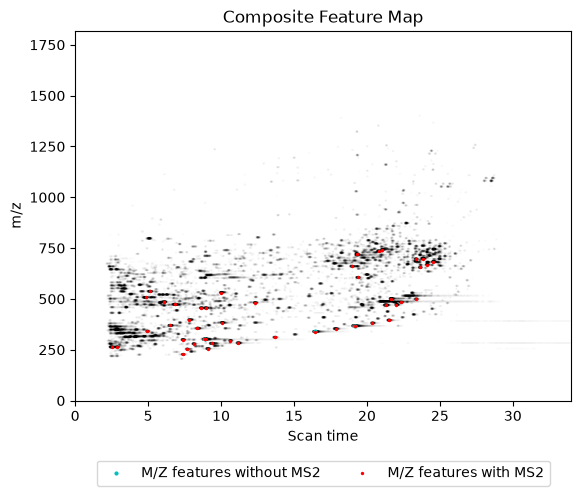

In [30]:
## The M/Z feature plot can now be generated with MS2 peaks identified (in red)
myLCMSobj.plot_composite_mz_features()

In [31]:
# MS2 spectra are now added to the main data frame (see column ms2_spectrum)
# Preview mass features table (full table can be large)
mf_df = myLCMSobj.mass_features_to_df()
print(f"Mass features: {len(mf_df)} rows × {mf_df.shape[1]} columns")
# Short readable preview (full table is wide)
_cols = [c for c in ["type", "scan_time", "mz", "apex_scan", "start_scan"] if c in mf_df.columns]
mf_df[_cols].head(5)


Mass features: 49 rows × 23 columns


,type,scan_time,mz,apex_scan,start_scan
mf_id,,,,,
0,untargeted,8.895637,301.216844,1882.0,1828
1,untargeted,19.152648,367.357482,4069.0,4024
2,untargeted,16.438137,339.326190,3484.0,3448
3,untargeted,8.378137,355.321396,1756.0,1729
4,untargeted,6.515803,369.300726,1297.0,1261


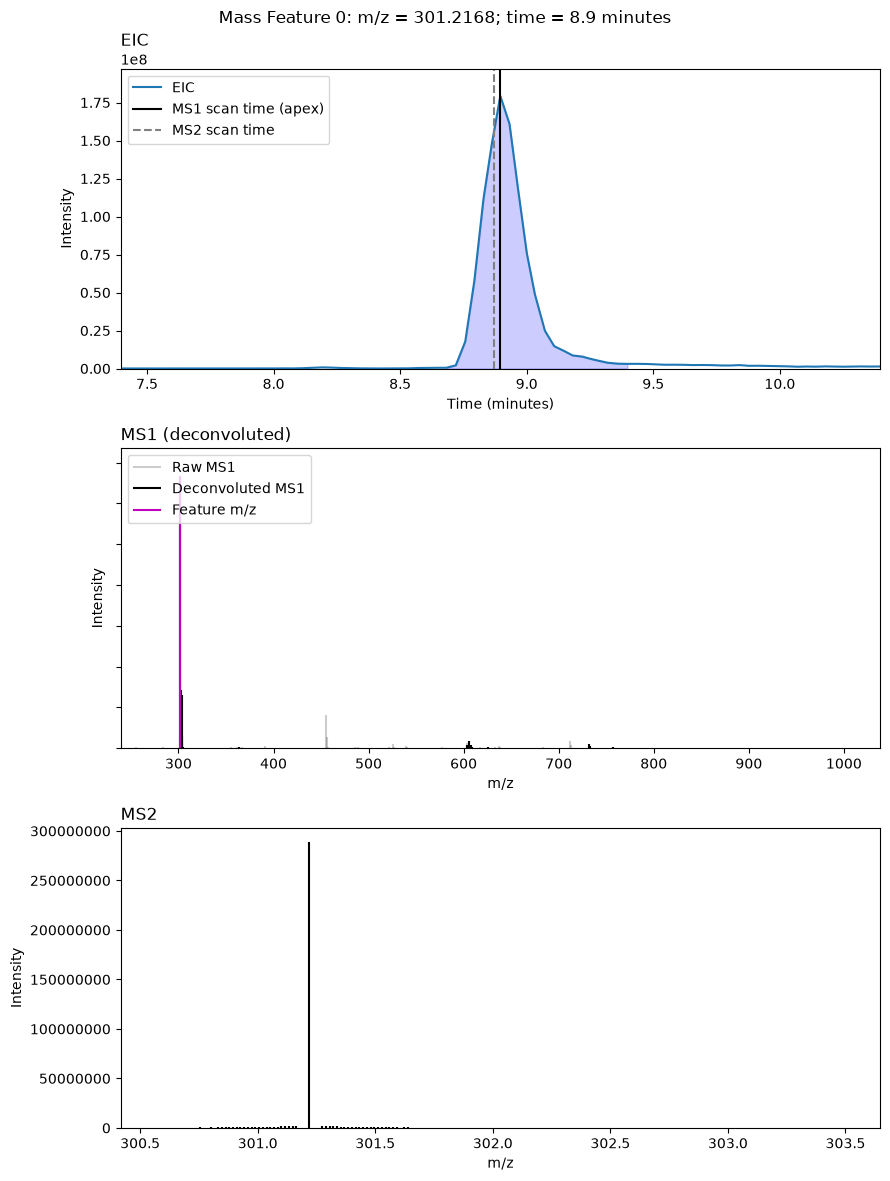

In [32]:
# Plot the MS2 spectrum associated with an M/Z feature
myLCMSobj.mass_features[0].plot(return_fig=False)

## MS2 Spectral Matching

Now we'll perform spectral matching on the MS2 data to annotate compounds using a reference spectral library. We'll use the MSP format metabolomics database and the FlashEntropy search algorithm for fast and accurate spectral matching.

> **Recommended for reproducibility:** rather than mutating `spectral_similarity_search` mid-notebook (as below), set these MS2 FlashEntropy / networking knobs on each file when you **initially process** it using a **template TOML** parameters file (`load_and_set_toml_parameters_lcms`). That stores the same settings with the LCMS object (and in exported HDF5 metadata), so library build, `fe_search`, and molecular networking all pick up a single, versionable configuration. Runtime overrides below are convenient for exploration and demos.


In [33]:
# Load the MSP spectral library database
msp_file_location = "../../tests/tests_data/lcms/test_db.msp"

# Initialize the MSP interface
my_msp = MSPInterface(file_path=msp_file_location)

# Configure spectral similarity settings on this LCMS object's MS2 profile so library
# build and later fe_search / networking use the same FlashEntropy knobs.
ss = myLCMSobj.parameters.mass_spectrum["ms2"].spectral_similarity_search
ss.max_ms2_tolerance_in_da = 0.01  # min peak separation is derived as 2x
ss.max_indexed_mz = 3000
ss.precursor_ions_removal_da = None
ss.noise_threshold = 0
ss.ms2_min_fe_score = 0.2  # annotation score gate for fe_search

# Get the spectral library in FlashEntropy format for negative mode
msp_negative, metabolite_metadata_negative = my_msp.get_metabolomics_spectra_library(
    polarity="negative",
    format="flashentropy",
    normalize=True,
    settings=settings_from_lcms(myLCMSobj, profile="ms2"),
)


In [34]:
# Get the HCD MS2 scans that were added to the LCMS object
hcd_ms2_scan_df = myLCMSobj.scan_df[
    myLCMSobj.scan_df.scan_text.str.contains("hcd")
    & (myLCMSobj.scan_df.ms_level == 2)
]

# Get the list of MS2 scan numbers that are actually in the LCMS object
ms2_scans_oi_hr = [
    x for x in hcd_ms2_scan_df.scan.tolist() if x in myLCMSobj._ms.keys()
]

print(f"Found {len(ms2_scans_oi_hr)} HCD MS2 scans to search")

Found 90 HCD MS2 scans to search


In [35]:
# Perform FlashEntropy spectral matching on the MS2 scans
# Score gate and default peak separation come from
# parameters.mass_spectrum["ms2"].spectral_similarity_search
myLCMSobj.fe_search(
    scan_list=ms2_scans_oi_hr,
    fe_lib=msp_negative,
)

print("MS2 spectral matching completed")


MS2 spectral matching completed


In [36]:
# Spectral match(es) for a single mass feature
mf = myLCMSobj.mass_features[1]
print(f"Number of MS2 similarity result sets: {len(mf.ms2_similarity_results)}")
df = mf.ms2_similarity_results[0].to_dataframe()
print(f"Matches in first result set: {len(df)}")
_cols = [c for c in [
    "precursor_mz", "query_spectrum_id", "ref_mol_id", "ref_ms_id",
    "entropy_similarity", "ref_ion_type", "database_name",
] if c in df.columns]
df[_cols].head(5)


Number of MS2 similarity result sets: 2
Matches in first result set: 1


,precursor_mz,query_spectrum_id,ref_mol_id,ref_ms_id,entropy_similarity,ref_ion_type,database_name
0,367.357482,4036,QZZGJDVWLFXDLK-UHFFFAOYSA-N,CCMSLIB00004684071,0.521133,[M-H]-,SUMNER.msp


In [37]:
# View the spectral matching results
# The spectral_similarity_results attribute contains the matches for each MS2 scan
# Examine the first mass feature that has MS2 data
results_df = []
for i, mf in myLCMSobj.mass_features.items():
    if mf.ms2_similarity_results:  # only proceed if there are good matches
        for ms2_sim_result in mf.ms2_similarity_results:
            results_df.append(ms2_sim_result.to_dataframe())
        break
results_df = pd.concat(results_df, ignore_index=True)
print("Spectral matching results for first M/Z feature with MS2 data:")
print(f"Mass Feature ID: {i}, M/Z: {mf.mz:.4f}, RT: {mf.retention_time:.2f} min")
print(f"Matches: {len(results_df)}")
_cols = [c for c in [
    "precursor_mz", "query_spectrum_id", "ref_mol_id", "ref_ms_id",
    "entropy_similarity", "ref_ion_type", "database_name",
] if c in results_df.columns]
results_df[_cols].head(5)


Spectral matching results for first M/Z feature with MS2 data:
Mass Feature ID: 1, M/Z: 367.3575, RT: 19.15 min
Matches: 2


,precursor_mz,query_spectrum_id,ref_mol_id,ref_ms_id,entropy_similarity,ref_ion_type,database_name
0,367.357482,4036,QZZGJDVWLFXDLK-UHFFFAOYSA-N,CCMSLIB00004684071,0.521133,[M-H]-,SUMNER.msp
1,367.357482,4070,QZZGJDVWLFXDLK-UHFFFAOYSA-N,CCMSLIB00004684071,0.539180,[M-H]-,SUMNER.msp


## Molecular Networking

Molecular networking connects **experimental** MS2 spectra to each other (and optionally
to a spectral library) using similarity scores. CoreMS supports **entropy similarity**
and optional **cosine**, with FlashEntropy modes **open**, **neutral_loss**, and
**identity**.

### Install (plotting / interactive)

Similarity scoring needs only CoreMS. Graph layout, static plots, clustering, and
interactive HTML need the optional extra:

```bash
pip install "corems[networking]"   # networkx + ipysigma
```

- **Static plot** (`plot_network`): `networkx` + `matplotlib` (via the extra)
- **Interactive HTML** (`plot_interactive_network`): also needs `ipysigma` (same extra)

### Typical flow

1. Prepare query spectra:
   - single sample: `MolecularNetwork.prepare_query_spectra_from_lcms_object(lcms)`
   - collection: `MolecularNetwork.prepare_query_spectra_from_lcms_collection(coll)`
2. Build the network:
   - all-in-one: `mn.query_vs_library(...)` (optional `hydrate_library_similarities=True`)
   - or staged: `run_query_vs_query_only` → `run_query_vs_library_stage` → optional
     `run_library_vs_library_stage`
3. Export edges with `save_edge_list` and plot with `plot_network` (static) or
   `plot_interactive_network` (HTML).

**Defaults:** `search_type="open"` (typical DDA). Cosine scoring is single-threaded.
Library nodes are stored as internal `lib:<idx>` IDs and mapped to FlashEntropy
`spectra_id` on CSV export.

**Interactive HTML example** (local Jupyter / browser only):

```python
mn.plot_interactive_network(
    metric="entropy_similarity",
    out_path="network.html",
    bypass_clustering=True,
)
```

### This notebook

Here we reuse the FlashEntropy library built above (`msp_negative`) and take query
spectra from this LC-MS run — each mass feature's `best_ms2` — via
`MolecularNetwork.prepare_query_spectra_from_lcms_object`.


In [38]:
# Collect experimental MS2 queries from mass features on this LCMS object.
# Prefer features that already have FlashEntropy library hits so the network
# includes query–library edges (not only query–query).
query_spectra, query_ids, query_precursor_mzs = (
    MolecularNetwork.prepare_query_spectra_from_lcms_object(myLCMSobj)
)

hit_mf_ids = {
    str(mf_id)
    for mf_id, mf in myLCMSobj.mass_features.items()
    if getattr(mf, "ms2_similarity_results", None)
}
# Stable order: spectral hits first, then remaining queries
ordered = sorted(
    zip(query_spectra, query_ids, query_precursor_mzs),
    key=lambda t: (0 if t[1] in hit_mf_ids else 1, t[1]),
)
query_spectra = [t[0] for t in ordered]
query_ids = [t[1] for t in ordered]
query_precursor_mzs = [t[2] for t in ordered]

print(f"Experimental MS2 queries from mass features: {len(query_spectra)}")
print(f"  of which have spectral library hits from fe_search: {sum(1 for qid in query_ids if qid in hit_mf_ids)}")

# Cap size for a readable tutorial figure / faster runtime
MAX_NETWORK_QUERIES = 50
if len(query_spectra) > MAX_NETWORK_QUERIES:
    query_spectra = query_spectra[:MAX_NETWORK_QUERIES]
    query_ids = query_ids[:MAX_NETWORK_QUERIES]
    query_precursor_mzs = query_precursor_mzs[:MAX_NETWORK_QUERIES]
    print(f"Using first {MAX_NETWORK_QUERIES} queries for the tutorial network (hits prioritized)")


Experimental MS2 queries from mass features: 46
  of which have spectral library hits from fe_search: 5


In [39]:
# Build a molecular network: experimental queries vs each other and vs the MSP library
# (same FE library used for fe_search above). Networking defaults come from the same
# spectral_similarity_search settings object; override thresholds for this demo so
# typical test_db.msp scores (~0.3–0.5) produce query–library edges.
ss = myLCMSobj.parameters.mass_spectrum["ms2"].spectral_similarity_search
ENTROPY_EDGE_THRESHOLD = 0.25
ss.search_type = "open"
ss.additional_similarities = ["cosine"]
ss.similarity_thresholds = {
    "entropy_similarity": ENTROPY_EDGE_THRESHOLD,
    "cosine": ENTROPY_EDGE_THRESHOLD,
}
ss.hydrate_library_similarities = True
ss.library_similarity_threshold = ENTROPY_EDGE_THRESHOLD

mn = MolecularNetwork(
    fe_lib=msp_negative,
    settings=ss,
)

mn.query_vs_library(
    query_spectra,
    query_ids,
    query_precursor_mzs=query_precursor_mzs,
)

edges = mn.get_network_edges(metric="entropy_similarity")
stats = mn.get_network_stats(metric="entropy_similarity")
query_id_set = set(query_ids)
ql_edges = [
    (a, b, s)
    for a, b, s in edges
    if (a in query_id_set) != (b in query_id_set)
]
qq_edges = [
    (a, b, s)
    for a, b, s in edges
    if a in query_id_set and b in query_id_set
]
print("Network stats (entropy_similarity):")
for k, v in stats.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")
print(f"  query–query edges: {len(qq_edges)}")
print(f"  query–library edges: {len(ql_edges)}")
print(f"\nTop edges (up to 10 of {len(edges)}):")
for a, b, score in sorted(edges, key=lambda x: -x[2])[:10]:
    kind = "Q–L" if (a in query_id_set) != (b in query_id_set) else "Q–Q"
    print(f"  [{kind}] {a} — {b}: {score:.4f}")


Network stats (entropy_similarity):
  metric: entropy_similarity
  threshold: 0.2500
  n_nodes: 51
  n_edges: 37
  avg_degree: 1.4510
  density: 0.0290
  query–query edges: 29
  query–library edges: 7

Top edges (up to 10 of 37):
  [Q–Q] 13 — 16: 1.0000
  [Q–Q] 2 — 18: 1.0000
  [Q–Q] 5 — 10: 1.0000
  [Q–Q] 18 — 27: 1.0000
  [Q–Q] 25 — 29: 1.0000
  [Q–Q] 26 — 41: 1.0000
  [Q–Q] 33 — 45: 1.0000
  [Q–Q] 1 — 24: 1.0000
  [Q–Q] 20 — 3: 1.0000
  [Q–Q] 10 — 6: 1.0000


Wrote edge list: ../../temp.corems/lcms_tutorial_molecular_network/edges_entropy_similarity.csv


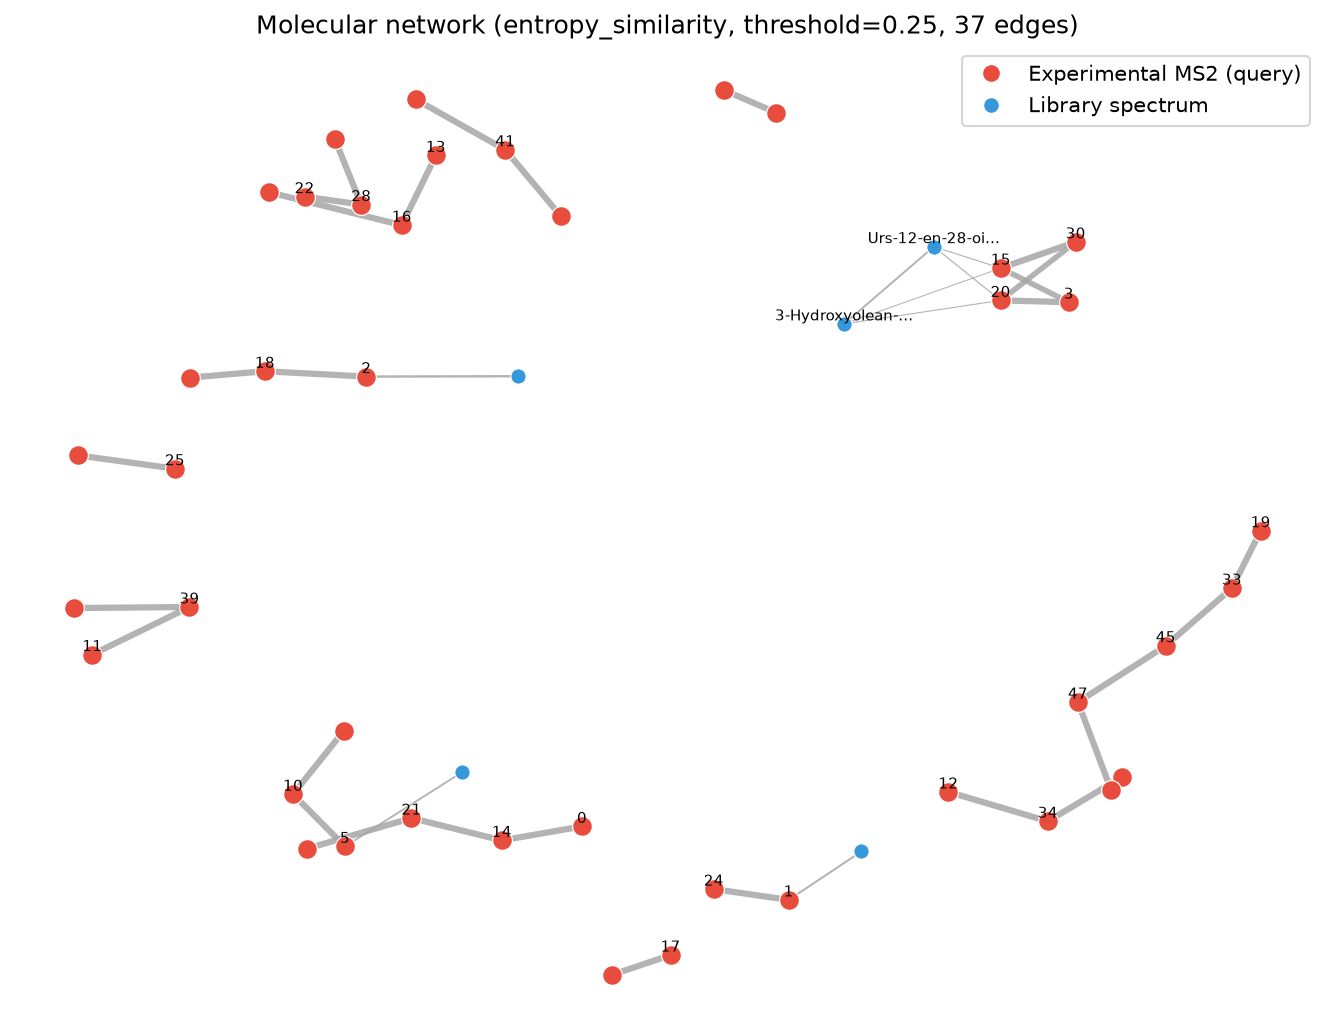

Wrote static network figure: ../../temp.corems/lcms_tutorial_molecular_network/network_entropy.png


In [40]:
# Export edge list and draw a static network snapshot (GitLab/GitHub-friendly)
network_out = Path("../../temp.corems") / "lcms_tutorial_molecular_network"
network_out.mkdir(parents=True, exist_ok=True)

edge_csv = network_out / "edges_entropy_similarity.csv"
mn.save_edge_list(str(edge_csv), metric="entropy_similarity")
print(f"Wrote edge list: {edge_csv}")

png_path = network_out / "network_entropy.png"
mn.plot_network(
    metric="entropy_similarity",
    path=str(png_path),
    max_edges=300,
    library_label_field=("compound_name", "name", "spectra_id"),
    bypass_clustering=True,
    show_labels=True,
    label_max_nodes=30,
)
print(f"Wrote static network figure: {png_path}")
# Interactive HTML (local only): mn.plot_interactive_network(..., out_path=..., bypass_clustering=True)


## Export data

In [41]:
# Export the LCMS object using the LCMSExport class
# Alternative export classes for Metabolomics and Lipidomics are available, see 
# see corems/corems/mass_spectra/output/export.py
# contains more functions to clean and summarize data
exporter = LCMSExport(
    "Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801", myLCMSobj
)

# Save report as HDF5 file
exporter.to_hdf(overwrite=True)

## Clean up files

In [42]:
# Delete the "Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.corems" directory
shutil.rmtree(
    "Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.corems",
    ignore_errors=True,
)